<a href="https://colab.research.google.com/github/alexander-toschev/cv-course/blob/main/semantic/Practise_semantic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📖 Scene Graph Generation Mini-Project

## 1. Установка и импорты

In [1]:

!pip install torch torchvision matplotlib networkx -q

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import networkx as nx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.6 MB/s eta 0:00:00


## 2. Загрузка модели и данных

In [2]:

# Загружаем предобученный Faster R-CNN
model = fasterrcnn_resnet50_fpn(pretrained=True)
model = model.eval()

# Загружаем изображение (замени на свое при необходимости)
!wget https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg -O test_image.jpg
image = Image.open('test_image.jpg').convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:02<00:00, 62.4MB/s]


--2025-04-29 15:08:34--  https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99389 (97K) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]  97.06K  --.-KB/s    in 0.05s   

2025-04-29 15:08:34 (1.86 MB/s) - ‘test_image.jpg’ saved [99389/99389]



## 3. Детекция объектов

In [3]:

# Детектируем объекты
with torch.no_grad():
    prediction = model(img_tensor)[0]

# Фильтрация объектов с высоким скором
threshold = 0.8
boxes = prediction['boxes'][prediction['scores'] > threshold]
labels = prediction['labels'][prediction['scores'] > threshold]

# Названия классов COCO
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

# Выводим объекты
for idx, box in enumerate(boxes):
    print(f"Object {idx}: {COCO_INSTANCE_CATEGORY_NAMES[labels[idx]]} - Box: {box.tolist()}")


Object 0: horse - Box: [77.60284423828125, 18.907333374023438, 536.2100830078125, 429.8861999511719]


## 4. Построение сцено-графа

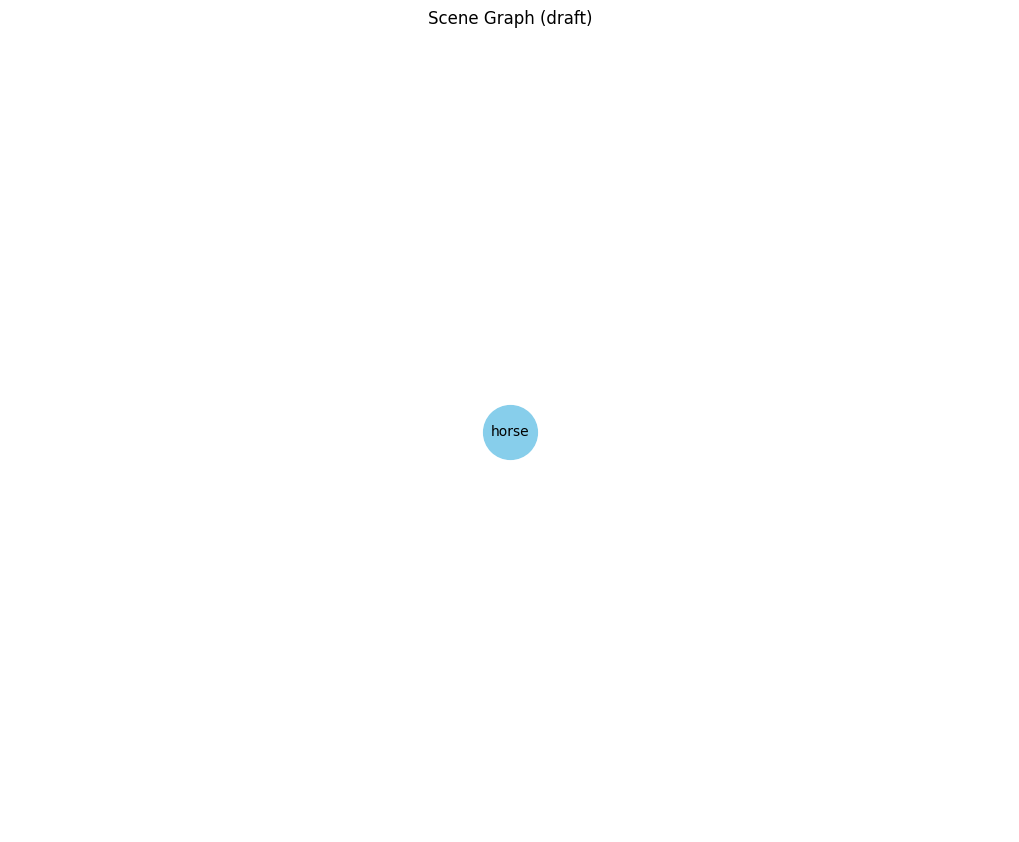

In [4]:

# Строим граф
G = nx.DiGraph()

# Добавляем объекты как узлы
for idx, label in enumerate(labels):
    G.add_node(idx, label=COCO_INSTANCE_CATEGORY_NAMES[label])

# Добавляем все возможные пары как ребра
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            G.add_edge(i, j, relation="unknown")

# Визуализация
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
labels_node = nx.get_node_attributes(G, 'label')
nx.draw(G, pos, with_labels=True, labels=labels_node, node_color='skyblue', node_size=1500, font_size=10, arrows=True)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Scene Graph (draft)")
plt.show()
